In [1]:
import zenidatasdk as zd
import alphalens as al
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import time
import os

pd.set_option('expand_frame_repr', False)
pd.set_option('display.max_rows', 1000)
pd.set_option('display.max_colwidth', 100)

In [2]:
# 检查版本
print(f"ZeniData SDK版本: {zd.__version__}")

# 创建客户端（测试基础功能）
client = zd.Client()
print("✅ 客户端创建成功")

# 登录账号，初始化 client 对象
client = zd.Client(
    username = "3191883175@qq.com",
    password = "Abc123456",
    base_url = "http://192.168.1.100:8000")
print("✅ 登录成功")

ZeniData SDK版本: 2.0.6
✅ 客户端创建成功
✅ 登录成功


In [3]:
# start_date =  "2016-01-01"                          # 定义所要回测的起始日期
# current_day = str(datetime.datetime.now().date())   # 使用现在作为结束日期
# get_index_constituents_df = (                       # 定义快捷的指数成分股表格获取
#     lambda index: client.get_index_constituents_df(index, start_date = start_date, end_date = current_day)
# )
#
# core_index_constituents_dict = {
#     index_code: get_index_constituents_df(index_code)
#     for index_code in [
#         rf"000300.XSHG",  # 沪深300
#         rf"000905.XSHG",  # 中证500
#         rf"000852.XSHG",  # 中证1000
#         rf"000016.XSHG",  # 上证50
#         rf"399006.XSHE",  # 创业板
#     ]
# }
#
# HS300 = core_index_constituents_dict[rf"000300.XSHG"]  # 沪深300
# ZZ500 = core_index_constituents_dict[rf"000905.XSHG"]  # 中证500
# ZZ1000 = core_index_constituents_dict[rf"000852.XSHG"]  # 中证1000
# SZ50 = core_index_constituents_dict[rf"000016.XSHG"]  # 上证50
# CYB = core_index_constituents_dict[rf"399006.XSHE"]  # 创业板
# # HS300.set_index(['datetime', 'symbol']).index.to_frame(index = False) # 把 index 复制一份作为列以生成表格
# display(HS300.head())
#
# symbols_df = client.get_symbols_df()  # 股票全集
# display(symbols_df.head())
#
# # symbols_df.info()
# # print(symbols_df.head())
# # print(symbols_df.tail())
# #
# # HS300.info()
# # print(HS300.head())
# # print(HS300.tail())

,datetime,index_symbol,update_date,symbol,weight,display_name
0,2016-01-04,000300.XSHG,2015-12-31,000001.XSHE,0.698,平安银行
1,2016-01-04,000300.XSHG,2015-12-31,000002.XSHE,1.929,万科A
2,2016-01-04,000300.XSHG,2015-12-31,000009.XSHE,0.233,中国宝安
3,2016-01-04,000300.XSHG,2015-12-31,000027.XSHE,0.119,深圳能源
4,2016-01-04,000300.XSHG,2015-12-31,000039.XSHE,0.158,中集集团


,symbol,name,short_name,start_date,end_date,update_time
0,000001.XSHE,平安银行,PAYH,1991-04-03,2200-01-01,2026-04-14 15:15:01.500
1,000002.XSHE,万科A,WKA,1991-01-29,2200-01-01,2026-04-14 15:15:01.500
2,000004.XSHE,*ST国华,*STGH,1990-12-01,2200-01-01,2026-04-14 15:15:01.500
3,000005.XSHE,ST星源,STXY,1990-12-10,2024-04-25,2026-04-14 15:15:01.500
4,000006.XSHE,深振业A,SZYA,1992-04-27,2200-01-01,2026-04-14 15:15:01.500


In [4]:
# # bars_df = client.get_bars(  # 则获取股票 OHLCV 数据
# #     symbol = rf"000001.XSHE",
# #     start_date = start_date,
# #     end_date = current_day,
# #     frequency = '1d',
# #     adjust_type = 'post',
# #     market = 'cn_stock'
# # )
# # bars_df.info()  # 查看最后一个股票的结构
# # print(bars_df.head())  # 打印 DataFrame 的首尾
# # print(bars_df.tail())  # 用于 copy/paste 方便询问 ai
#
# # 定义需要的列
# OHLCV_columns = ['datetime', 'symbol', 'open', 'high', 'low', 'close', 'volume', 'amount']
#
# def fetch_stock_data(symbol_info):
#     """获取单只股票数据并预处理"""
#     symbol = symbol_info['symbol']
#     bars_date = client.get_bars(
#         symbol = symbol,
#         start_date = start_date,
#         end_date = current_day,
#         frequency = '1d',
#         adjust_type = 'post',
#         market = 'cn_stock'
#     )
#
#     if bars_date is None or bars_date.empty:
#         return None
#
#     bars_date = bars_date[OHLCV_columns].copy() # 只保留需要的列，减少内存占用
#     bars_date = bars_date.set_index(['datetime', 'symbol'])  # 立即设置索引
#     return bars_date

In [ ]:
# from tqdm import tqdm
# from concurrent.futures import ThreadPoolExecutor, as_completed # concurrent.futures 是 Python 标准库中的一个模块，用于实现异步并行任务处理。
# # ThreadPoolExecutor：基于线程池，适合 I/O 密集型任务
# # ProcessPoolExecutor：基于进程池，适合 CPU 密集型任务
#
# # Future 对象，代表异步操作的的结果容器。其状态不是属性而被设计为方法
# #     future.cancelled(): 在队列中等待分配线程
# #     future.running(): 正在某个 Worker 线程中执行
# #     future.done(): 已完成，即有结果或异常
#
# # Executor 类，管理任务执行
# # as_completed()，按完成顺序获取结果
# # wait()，等待任务完成
#
# MAX_WORKERS = 4  # 线程池大小，根据 API 限流调整
# data_chunks = [] # 数据块列表
#
# with ThreadPoolExecutor(max_workers = MAX_WORKERS) as executor:
#     # 提交所有任务
#     future_to_symbol = {
#         executor.submit(fetch_stock_data, row): row['symbol']
#         for _, row in symbols_df.iterrows()
#     }
#     # executor.submit(function, *args)，将函数 fetch_stock_data 提交到线程池队列，立即返回一个 Future 对象，不等待执行完成
#     # future_to_symbol 字典键为 Future 对象，即异步操作的结果容器
#     # 值为对应的股票代码
#
#     # 收集结果
#     for future in tqdm(as_completed(future_to_symbol), total = len(symbols_df)):
#         # as_completed(future_dict) 谁先完成就返回谁，不按提交顺序，
#         # 当第 1000 只股票还在慢速下载时，第 1001 只可能已经完成了，as_completed 不会阻塞等待第 1000 只，而是立即 yield 第 1001 只的 Future
#         # 如果用 future_list = list(future_to_symbol.keys()) 然后顺序遍历，就会阻塞等待每只按顺序完成
#         result = future.result()
#         if result is not None:
#             data_chunks.append(result)
#
# print(rf"Merging {len(data_chunks)} chunks...")
# big_df = pd.concat(data_chunks, axis = 0)
# big_df = big_df.sort_index() # 确保索引有序，提高后续查询效率
#
# print(f"Final DataFrame shape: {big_df.shape}")
# print(f"Memory usage: {big_df.memory_usage().sum() / 1024**2:.2f} MB")

In [ ]:
# if 'big_df' in locals():
#     big_df.to_csv(r"C:\Users\zy\Desktop\tmp_Dataset\big_df.csv", index = True)
#     pass
# else:
#     big_df = pd.read_csv(r"C:\Users\zy\Desktop\tmp_Dataset\big_df.csv")
#     big_df['datetime'] = pd.to_datetime(big_df['datetime'])
#     big_df = big_df.set_index(['datetime', 'symbol'])

In [3]:
# 历史回测区间
init_date = '2015-01-01'
start_date = '2016-01-01'
end_date = str(datetime.today().date())
index_symbol = rf"000852.XSHG"

In [4]:
# 获取指数成分股数据据
index_weights_df = client.get_index_constituents_df(
    index_symbol = index_symbol,
    start_date = start_date,
    end_date = end_date
)
index_weights_df = index_weights_df.rename(columns = {"date": "datetime"})
symbols = index_weights_df["symbol"].unique().tolist()
index_weights_df

,datetime,index_symbol,update_date,symbol,weight,display_name
0,2016-01-04,000852.XSHG,2015-12-31,000008.XSHE,0.158,神州高铁
1,2016-01-04,000852.XSHG,2015-12-31,000010.XSHE,0.066,美丽生态
2,2016-01-04,000852.XSHG,2015-12-31,000011.XSHE,0.043,深物业A
3,2016-01-04,000852.XSHG,2015-12-31,000014.XSHE,0.051,沙河股份
4,2016-01-04,000852.XSHG,2015-12-31,000016.XSHE,0.143,深康佳A
...,...,...,...,...,...,...
2495995,2026-04-15,000852.XSHG,2026-03-31,688776.XSHG,0.055,国光电气
2495996,2026-04-15,000852.XSHG,2026-03-31,688779.XSHG,0.143,五矿新能
2495997,2026-04-15,000852.XSHG,2026-03-31,688789.XSHG,0.084,宏华数科
2495998,2026-04-15,000852.XSHG,2026-03-31,688798.XSHG,0.073,艾为电子


In [5]:
# 获取日频bar数据
bars_1d_df = client.kline.get_kline_df(
    symbol = symbols,
    start_date = init_date,
    end_date = end_date,
    frequency = "1d",
    adjust_type = "post", # post, pre
    market = "cn_stock"
)
bars_1d_df

,open,high,low,close,pre_close,high_limit,low_limit,avg,volume,datetime,symbol,amount,paused
0,41.91,41.91,41.91,41.91,41.91,41.91,41.91,41.91,0.00,2015-01-05,000005.XSHE,0.000000e+00,1.0
1,293.19,305.17,289.89,292.37,291.13,320.45,262.22,296.91,2612052.60,2015-01-05,000006.XSHE,7.753464e+08,0.0
2,134.21,139.86,131.18,131.78,134.15,147.57,120.73,135.61,377088.42,2015-01-05,000008.XSHE,5.113300e+07,0.0
3,98.37,98.37,98.37,98.37,98.37,98.37,98.37,98.37,0.00,2015-01-05,000010.XSHE,0.000000e+00,1.0
4,34.96,36.10,34.23,34.93,34.51,37.97,31.05,35.24,5780467.90,2015-01-05,000011.XSHE,2.037845e+08,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6097354,11.31,11.50,11.21,11.46,11.22,13.46,8.98,11.34,32832501.09,2026-04-14,688779.XSHG,3.724553e+08,0.0
6097355,123.23,123.89,121.36,123.19,122.74,147.30,98.19,122.44,765902.56,2026-04-14,688788.XSHG,9.377682e+07,0.0
6097356,153.75,154.71,148.87,151.43,153.13,183.75,122.50,150.33,878178.55,2026-04-14,688789.XSHG,1.320197e+08,0.0
6097357,95.38,96.23,94.39,95.20,94.63,113.56,75.71,95.18,1994524.75,2026-04-14,688798.XSHG,1.898332e+08,0.0


In [6]:
# 获取行业数据
industry_constituents_df = client.get_industry_constituents_composite_df(
    symbols = symbols,
    category = "sw_l1",
    start_date = start_date,
    end_date = end_date
)

# 构建双重索引的行业数据
industries = industry_constituents_df.set_index(["datetime", "symbol"])["industry_name"]
industries

datetime    symbol     
2016-01-04  000034.XSHE    农林牧渔I
            000048.XSHE    农林牧渔I
            000592.XSHE    农林牧渔I
            000639.XSHE    农林牧渔I
            000713.XSHE    农林牧渔I
                           ...  
2026-04-15  600315.XSHG    美容护理I
            603193.XSHG    美容护理I
            603605.XSHG    美容护理I
            603983.XSHG    美容护理I
            605009.XSHG    美容护理I
Name: industry_name, Length: 5750861, dtype: object

In [7]:
# ================ 生成 alphalens 要求的价格表参数 ================

# 多资产价格数据(开盘价买入)
prices_df = bars_1d_df[bars_1d_df["datetime"] >= start_date]
prices = prices_df.pivot(index = 'datetime', columns = 'symbol', values = 'open')  # 再透视为 alphalens 要求的格式
prices.head(10).T.head(10).T # 取一小片数据以演示格式

symbol,000005.XSHE,000006.XSHE,000008.XSHE,000010.XSHE,000011.XSHE,000012.XSHE,000014.XSHE,000016.XSHE,000018.XSHE,000019.XSHE
datetime,,,,,,,,,,
2016-01-04,102.23,476.84,313.85,135.06,50.80,273.77,206.45,154.58,91.44,54.61
2016-01-05,83.42,401.53,255.99,113.92,43.35,233.13,172.57,128.18,76.73,46.36
2016-01-06,91.19,418.59,290.33,114.19,43.87,241.38,174.38,133.77,82.80,46.26
2016-01-07,92.42,421.50,284.79,116.45,43.70,241.18,172.75,133.77,82.45,46.81
2016-01-08,88.02,396.12,271.58,109.93,41.08,228.18,163.99,125.50,78.54,42.54
2016-01-11,83.42,386.96,263.92,103.69,39.16,217.86,159.02,119.90,79.36,40.63
2016-01-12,76.37,355.34,263.65,96.77,35.66,204.25,146.37,110.28,76.67,37.56
2016-01-13,77.69,354.92,255.20,98.24,36.71,210.44,150.07,109.61,80.04,37.66
2016-01-14,70.54,341.19,224.55,88.27,33.91,191.04,132.63,104.02,68.46,33.22


In [45]:
# ================  生成 zylh 规范的因子计算函数  ==================

def f_abnretavg_000(bars: pd.DataFrame, f_name = 'f_0001', min_periods: int = 5) -> pd.DataFrame:
    """
    factor_intro: 平均异常日收益率因子
    category: ！！！！！！！
    category_intro: ！！！！
    subcategory: ！！！
    subcategory_intro: 异常收益率
    min_periods: 5
    source: 写参考文献！！！！！
    author: 魏丰协

    说明：
    计算逻辑概述：

    Parameters
    ----------
    bars: pd.DataFrame
        日频, bars
        ['datetime', 'symbol', 'open', 'high', 'low', 'close', 'volume']
    f_name: str
        因子名称
    min_periods: int
        计算窗口期，默认为20（1个月交易日）

    Returns
    -------
    pd.DataFrame
        因子值，包含列：['datetime', 'symbol', 'factor_name', 'factor_value']
    """

    rolling_window_len = 60
    df = bars.copy()

    bars['return'] = bars.groupby('symbol')['close'].transform(
        lambda close: (close - close.shift(1)) / close.shift(1)
    )
    bars['avg_return'] = bars.groupby('datetime')['return'].transform('mean')
    bars['abnormal_return'] = (bars['return'] - bars['avg_return']) ** 2
    bars['abnretavg'] = bars.groupby('symbol')['abnormal_return'].transform(
        lambda x: x.rolling(window = rolling_window_len, min_periods = min_periods).mean()
    )

    abnretavg_long = bars.reset_index()
    abnretavg_long = abnretavg_long.rename(columns = {'abnretavg': 'factor_value'})
    abnretavg_long = abnretavg_long[['datetime', 'symbol', 'factor_value']]
    abnretavg_long['factor_name'] = f_name
    abnretavg_long = abnretavg_long[['datetime', 'symbol', 'factor_name', 'factor_value']]

    return abnretavg_long

def f_momentum20D_001(bars: pd.DataFrame, f_name = 'f_0001', min_periods: int = 20) -> pd.DataFrame:
    """
    factor_intro: 1个月动量因子，20日收益率
    category: momentum
    category_intro: 动量类因子
    subcategory: short_term_momentum
    subcategory_intro: 短期动量
    min_periods: 20
    source: None
    author: 魏丰协

    Parameters
    ----------
    bars: pd.DataFrame
        日频, bars
        ['datetime', 'symbol', 'open', 'high', 'low', 'close', 'volume']
    f_name: str
        因子名称
    min_periods: int
        计算窗口期，默认为20（1个月交易日）

    Returns
    -------
    pd.DataFrame
        因子值，包含列：['datetime', 'symbol', 'factor_name', 'factor_value']
    """
    close_2dim = bars.reset_index()[                                        # 透视为二维交叉表
        ['datetime', 'symbol', 'close']
    ].pivot(
        index = 'datetime',
        columns = 'symbol',
        values = 'close'
    )
    close_2dim = close_2dim.ffill()
    momentum_2dim = close_2dim.pct_change(periods = min_periods)            # 计算变动率
    momentum_long = momentum_2dim.reset_index().melt(                       # 融列为长表
        id_vars = ['datetime'],
        var_name = 'symbol',
        value_name = 'factor_value'
    ).dropna()

    momentum_long.columns = ['datetime', 'symbol', 'factor_value']          # 对列名重命名
    momentum_long['factor_name'] = rf"momentum_{min_periods}"               # 添加因子名称列以方便库管理

    momentum_long = momentum_long[['datetime', 'symbol', 'factor_name', 'factor_value']].copy()
    return momentum_long

def f_alpha001(bars: pd.DataFrame, f_name: str = 'f_alpha001', min_periods: int = 5) -> pd.DataFrame:
    """
    factor_intro: Alpha #001 因子，基于价格与波动性的均值回归策略。当收益率小于0时取20日收益率标准差，否则取收盘价；
                 经SignedPower平方放大差异后，取过去5日最大值的索引（距今天数），最后横截面排名中性化。
    category: alpha001
    category_intro: 均值回归类因子，利用"跌久必弹"及波动性原理，识别价格极值点产生交易信号
    subcategory: None
    subcategory_intro: WorldQuant经典Alpha因子
    min_periods: 5
    source: WorldQuant Alpha #001
    author: KIMI

    Parameters
    ----------
    bars: pd.DataFrame
        日频, bars
        ['datetime', 'symbol', 'open', 'high', 'low', 'close', 'volume']
    f_name: str
        因子名称
    min_periods: int
        计算窗口期最小值，默认为5（用于Ts_ArgMax的5日窗口及stddev的20日窗口）

    Returns
    -------
    pd.DataFrame
        因子值，包含列：['datetime', 'symbol', 'factor_name', 'factor_value']
    """

    df = bars.copy()

    # 1. 计算收益率 returns = (close - close.shift(1)) / close.shift(1)
    df['returns'] = df.groupby('symbol')['close'].transform(
        lambda x: x.pct_change()
    )

    # 2. 计算20日收益率标准差 stddev(returns, 20)
    df['stddev_20'] = df.groupby('symbol')['returns'].transform(
        lambda x: x.rolling(window=20, min_periods=min_periods).std()
    )

    # 3. 条件选择: x1 = (returns < 0 ? stddev(returns,20) : close)
    # 当收益率为负时取波动率，否则取收盘价
    df['x1'] = np.where(df['returns'] < 0, df['stddev_20'], df['close'])

    # 4. SignedPower(x1, 2) = Sign(x1) * Abs(x1)^2
    # 由于close和stddev均为正，实际效果为平方放大
    df['x2'] = np.sign(df['x1']) * np.power(np.abs(df['x1']), 2)

    # 5. Ts_ArgMax(x2, 5): 过去5日最大值的"年龄"（距今天数）
    # 返回1-5的整数，1表示过去第1天（昨天），5表示过去第5天
    def ts_argmax_age(x):
        """
        计算序列中最大值距离当前的天数（1-indexed）
        例如：5日窗口中，若最大值在第1个位置（最早），返回5；在最后1个位置（最近），返回1
        """
        if len(x) == 0:
            return np.nan
        # 忽略NaN值进行计算
        valid_mask = ~np.isnan(x)
        if not np.any(valid_mask):
            return np.nan
        # 找到最大值的位置（0-indexed）
        max_idx = np.argmax(x)
        # 转换为年龄：窗口长度 - 索引
        return len(x) - max_idx

    df['x3'] = df.groupby('symbol')['x2'].transform(
        lambda x: x.rolling(window=5, min_periods=min_periods).apply(ts_argmax_age, raw=True)
    )

    # 6. rank(x3) - 0.5: 横截面百分比排名并中心化（-0.5至0.5）
    # 值越大表示距离极值点越远（过去第5天 > 过去第1天），根据均值回归理论，反弹概率越高
    df['factor_value'] = df.groupby('datetime')['x3'].transform(
        lambda x: x.rank(pct=True, method='min') - 0.5
    )

    # 7. 整理输出格式
    result = df[['datetime', 'symbol', 'factor_value']].reset_index(drop=True)
    result['factor_name'] = f_name
    result = result[['datetime', 'symbol', 'factor_name', 'factor_value']]

    return result

def f_alpha002(bars: pd.DataFrame, f_name: str = 'f_alpha002', min_periods: int = 6) -> pd.DataFrame:
    """
    factor_intro: Alpha #002 因子，基于成交量变化与价格变动的相关性，衡量量价背离程度。
                 计算成交量对数变化的排名与日内收益率排名的6日滚动相关系数，并取负号。
    category: alpha002
    category_intro: 量价相关性类因子，捕捉量价背离带来的均值回归机会
    subcategory: None
    subcategory_intro: WorldQuant经典Alpha因子，基于"价量背离"原理
    min_periods: 6
    source: WorldQuant Alpha #002
    author: 系统实现

    Parameters
    ----------
    bars: pd.DataFrame
        日频, bars
        ['datetime', 'symbol', 'open', 'high', 'low', 'close', 'volume']
    f_name: str
        因子名称
    min_periods: int
        计算窗口期最小值，默认为6（correlation的6日窗口）

    Returns
    -------
    pd.DataFrame
        因子值，包含列：['datetime', 'symbol', 'factor_name', 'factor_value']
    """

    df = bars.copy()

    # 1. 计算 log(volume)
    df['log_volume'] = np.log(df['volume'])

    # 2. 计算 delta(log(volume), 2): 成交量对数的2日变化
    df['delta_log_vol'] = df.groupby('symbol')['log_volume'].transform(
        lambda x: x - x.shift(2)
    )

    # 3. 计算日内收益率 (close - open) / open
    df['intraday_ret'] = (df['close'] - df['open']) / df['open']

    # 4. 横截面排名 rank(delta(log(volume),2))
    df['rank_delta_vol'] = df.groupby('datetime')['delta_log_vol'].transform(
        lambda x: x.rank(pct=True, method='min')
    )

    # 5. 横截面排名 rank((close-open)/open)
    df['rank_ret'] = df.groupby('datetime')['intraday_ret'].transform(
        lambda x: x.rank(pct=True, method='min')
    )

    # 6. 计算6日滚动相关系数 correlation(x, y, 6)
    def rolling_corr(group):
        return group['rank_delta_vol'].rolling(window=6, min_periods=min_periods).corr(
            group['rank_ret']
        )

    df['corr'] = df.groupby('symbol', group_keys=False).apply(rolling_corr)

    # 7. 取负号: -1 * correlation
    df['factor_value'] = -1 * df['corr']

    # 8. 整理输出格式
    result = df[['datetime', 'symbol', 'factor_value']].reset_index(drop=True)
    result['factor_name'] = f_name
    result = result[['datetime', 'symbol', 'factor_name', 'factor_value']]

    return result

def f_alpha003(bars: pd.DataFrame, f_name: str = 'f_alpha003', min_periods: int = 10) -> pd.DataFrame:
    """
    factor_intro: Alpha #003 因子，基于开盘价与成交量的秩相关系数，衡量开盘量价配合程度。
                 计算开盘价排名的10日滚动相关系数与成交量排名，并取负号。
    category: alpha003
    category_intro: 量价相关性类因子，捕捉开盘量价背离的均值回归机会
    subcategory: None
    subcategory_intro: WorldQuant经典Alpha因子，基于"开盘量价背离"原理
    min_periods: 10
    source: WorldQuant Alpha #003
    author: 系统实现

    Parameters
    ----------
    bars: pd.DataFrame
        日频, bars
        ['datetime', 'symbol', 'open', 'high', 'low', 'close', 'volume']
    f_name: str
        因子名称
    min_periods: int
        计算窗口期最小值，默认为10（correlation的10日窗口）

    Returns
    -------
    pd.DataFrame
        因子值，包含列：['datetime', 'symbol', 'factor_name', 'factor_value']
    """

    df = bars.copy()

    # 1. 横截面排名 rank(open): 开盘价在所有股票中的排名
    df['rank_open'] = df.groupby('datetime')['open'].transform(
        lambda x: x.rank(pct=True, method='min')
    )

    # 2. 横截面排名 rank(volume): 成交量在所有股票中的排名
    df['rank_volume'] = df.groupby('datetime')['volume'].transform(
        lambda x: x.rank(pct=True, method='min')
    )

    # 3. 计算10日滚动相关系数 correlation(rank(open), rank(volume), 10)
    def rolling_corr(group):
        return group['rank_open'].rolling(window=10, min_periods=min_periods).corr(
            group['rank_volume']
        )

    df['corr'] = df.groupby('symbol', group_keys=False).apply(rolling_corr)

    # 4. 取负号: -1 * correlation
    # 逻辑：当开盘价排名与成交量排名正相关时（量价齐升），做空；负相关时（量价背离），做多
    df['factor_value'] = -1 * df['corr']

    # 5. 整理输出格式
    result = df[['datetime', 'symbol', 'factor_value']].reset_index(drop=True)
    result['factor_name'] = f_name
    result = result[['datetime', 'symbol', 'factor_name', 'factor_value']]

    return result

def f_alpha004(bars: pd.DataFrame, f_name: str = 'f_alpha004', min_periods: int = 5) -> pd.DataFrame:
    """
    factor_intro: Alpha #004 因子，基于最低价时序排名的均值回归策略。
                 对最低价进行横截面排名后，计算9日时序排名并取负号。
                 当最低价处于过去9日高位时做空，处于低位时做多。
    category: alpha004
    category_intro: 价格动量类因子，利用最低价位置的均值回归特性
    subcategory: None
    subcategory_intro: WorldQuant经典Alpha因子，基于"最低价极值回归"原理
    min_periods: 5
    source: WorldQuant Alpha #004
    author: 系统实现

    Parameters
    ----------
    bars: pd.DataFrame
        日频, bars
        ['datetime', 'symbol', 'open', 'high', 'low', 'close', 'volume']
    f_name: str
        因子名称
    min_periods: int
        计算窗口期最小值，默认为5（ts_rank的9日窗口至少需要5个数据点）

    Returns
    -------
    pd.DataFrame
        因子值，包含列：['datetime', 'symbol', 'factor_name', 'factor_value']
    """

    df = bars.copy()

    # 1. 横截面排名 rank(low): 最低价在所有股票中的排名（百分比）
    df['rank_low'] = df.groupby('datetime')['low'].transform(
        lambda x: x.rank(pct=True, method='min')
    )

    # 2. 时序排名 ts_rank(rank(low), 9): 过去9日排名的时序排名
    # ts_rank返回过去d天中当前值的位置（百分比），1表示过去d天最大值，0表示最小值
    def ts_rank_pct(x):
        """
        计算时间序列排名百分比
        返回当前值在过去d天中的百分位排名（0-1）
        """
        if len(x) == 0:
            return np.nan
        # 忽略NaN值
        valid_mask = ~np.isnan(x)
        if not np.any(valid_mask):
            return np.nan
        # 当前值为序列最后一个值
        current_val = x[-1]
        # 计算排名百分比
        # pct=True: (排名-1)/(总数-1)
        ranks = pd.Series(x).rank(pct=True, method='min')
        return ranks.iloc[-1]

    df['ts_rank_low'] = df.groupby('symbol')['rank_low'].transform(
        lambda x: x.rolling(window=9, min_periods=min_periods).apply(ts_rank_pct, raw=True)
    )

    # 3. 取负号: -1 * ts_rank(rank(low), 9)
    # 逻辑：当最低价处于过去9日高位时（ts_rank接近1），因子接近-1，做空；
    #      当最低价处于过去9日低位时（ts_rank接近0），因子接近0，做多
    df['factor_value'] = -1 * df['ts_rank_low']

    # 4. 整理输出格式
    result = df[['datetime', 'symbol', 'factor_value']].reset_index(drop=True)
    result['factor_name'] = f_name
    result = result[['datetime', 'symbol', 'factor_name', 'factor_value']]

    return result

def f_alpha005(bars: pd.DataFrame, f_name: str = 'f_alpha005', min_periods: int = 5) -> pd.DataFrame:
    """
    factor_intro: Alpha #005 因子，基于开盘价与VWAP偏离度以及收盘价与VWAP偏离度的乘积。
                 计算开盘价相对10日VWAP均值的排名，乘以收盘价相对当日VWAP排名的绝对值的负值。
    category: alpha005
    category_intro: 价格偏离类因子，捕捉开盘与收盘相对VWAP位置的背离关系
    subcategory: None
    subcategory_intro: WorldQuant经典Alpha因子，基于"VWAP偏离"原理
    min_periods: 5
    source: WorldQuant Alpha #005
    author: 系统实现

    Parameters
    ----------
    bars: pd.DataFrame
        日频, bars
        ['datetime', 'symbol', 'open', 'high', 'low', 'close', 'volume']
    f_name: str
        因子名称
    min_periods: int
        计算窗口期最小值，默认为5（10日移动平均至少需要5个数据点）

    Returns
    -------
    pd.DataFrame
        因子值，包含列：['datetime', 'symbol', 'factor_name', 'factor_value']
    """

    df = bars.copy()

    # 1. 计算vwap（典型价格作为近似，若后续有amount字段可替换为amount/volume）
    # vwap = (high + low + close) / 3
    df['vwap'] = (df['high'] + df['low'] + df['close']) / 3

    # 2. 计算10日vwap均值 sum(vwap,10)/10
    df['vwap_10_mean'] = df.groupby('symbol')['vwap'].transform(
        lambda x: x.rolling(window=10, min_periods=min_periods).mean()
    )

    # 3. 计算开盘价与10日vwap均值的差: open - (sum(vwap,10)/10)
    df['open_deviation'] = df['open'] - df['vwap_10_mean']

    # 4. 横截面排名 rank(open-(sum(vwap,10)/10))
    df['rank_open_dev'] = df.groupby('datetime')['open_deviation'].transform(
        lambda x: x.rank(pct=True, method='min')
    )

    # 5. 计算收盘价与当日vwap的差: close - vwap
    df['close_deviation'] = df['close'] - df['vwap']

    # 6. 横截面排名 rank(close-vwap)
    df['rank_close_dev'] = df.groupby('datetime')['close_deviation'].transform(
        lambda x: x.rank(pct=True, method='min')
    )

    # 7. 计算 (-1*abs(rank((close-vwap))))
    df['abs_rank_close'] = -1 * np.abs(df['rank_close_dev'])

    # 8. 最终因子: rank((open-(sum(vwap,10)/10))) * (-1*abs(rank((close-vwap))))
    df['factor_value'] = df['rank_open_dev'] * df['abs_rank_close']

    # 9. 整理输出格式
    result = df[['datetime', 'symbol', 'factor_value']].reset_index(drop=True)
    result['factor_name'] = f_name
    result = result[['datetime', 'symbol', 'factor_name', 'factor_value']]

    return result

In [47]:
# 计算因子数据
factors_df = f_alpha003(
    bars = bars_1d_df,
    f_name = 'abnretavg',
    min_periods = 5,
) # 因子函数 func()
# 因子值 shift 1 转换成实际使用时间(T+1)
factors_df["factor_value"] = factors_df.groupby('symbol')['factor_value'].transform(lambda x: x.shift(1))
factors_df

,datetime,symbol,factor_name,factor_value
0,2015-01-05,000005.XSHE,abnretavg,NaN
1,2015-01-05,000006.XSHE,abnretavg,NaN
2,2015-01-05,000008.XSHE,abnretavg,NaN
3,2015-01-05,000010.XSHE,abnretavg,NaN
4,2015-01-05,000011.XSHE,abnretavg,NaN
...,...,...,...,...
6096147,2026-04-14,688779.XSHG,abnretavg,-0.129693
6096148,2026-04-14,688788.XSHG,abnretavg,-0.178553
6096149,2026-04-14,688789.XSHG,abnretavg,-0.163568
6096150,2026-04-14,688798.XSHG,abnretavg,-0.020408


In [ ]:
# =================== 转换为 alphalens 要求的因子格式 ======================

# 与指数的交易日历、历史成分股数据对齐
factors_df = pd.merge(index_weights_df[["datetime", "symbol"]], factors_df, how = "left", on = ["datetime", "symbol"])
# 转换成[datetime, symbol]双重索引的factor_table
factors = factors_df.pivot_table(index = ["datetime", "symbol"], columns = "factor_name", values = "factor_value")

# if True: factors['abnretavg'] *= -1
factors

In [49]:
# ==================== Alphalens 因子分析 ====================

# 调用alphalens进行数据清洗
factor_data = al.utils.get_clean_factor_and_forward_returns(
    factor=factors,
    prices=prices,
    periods=(1, 5, 20),
    bins=None,
    quantiles=7,
    groupby=None,
    groupby_labels=None,
    binning_by_group=False,
    filter_zscore=20,
    max_loss=1,
    zero_aware=False,
    cumulative_returns=True
)
factor_data

Dropped 0.9% entries from factor data: 0.9% in forward returns computation and 0.0% in binning phase (set max_loss=0 to see potentially suppressed Exceptions).
max_loss is 100.0%, not exceeded: OK!


1D        5D       20D    factor  factor_quantile
date       asset                                                               
2016-01-04 000008.XSHE -0.184356 -0.159089 -0.294631  0.070454                6
           000010.XSHE -0.156523 -0.232267 -0.184066 -0.176125                5
           000011.XSHE -0.146654 -0.229134 -0.326969 -0.462676                3
           000014.XSHE -0.164108 -0.229741 -0.260402 -0.507855                3
           000016.XSHE -0.170785 -0.224350 -0.400893 -0.284993                4
...                          ...       ...       ...       ...              ...
2026-03-16 688776.XSHG -0.083979 -0.226926 -0.262006 -0.477436                4
           688779.XSHG  0.012386 -0.099917 -0.066061  0.314760                7
           688789.XSHG -0.008778 -0.063387 -0.094256  0.058136                6
           688798.XSHG  0.014198 -0.053934 -0.059554 -0.699397                2
           688800.XSHG  0.104382  0.014032  0.071024 -0.597317                2

[2470022 rows x 5 columns]

Quantiles Statistics


,min,max,mean,std,count,count %
factor_quantile,,,,,,
1,-1.031035,-0.465886,-0.767780,0.085052,353363,14.306067
2,-0.795365,-0.249191,-0.563926,0.076626,353124,14.296391
3,-0.654742,-0.060262,-0.392264,0.087742,352977,14.290440
4,-0.510796,0.194354,-0.221290,0.097913,351174,14.217444
5,-0.385175,0.408026,-0.037947,0.106056,352901,14.287363
6,-0.206051,0.656073,0.177944,0.115294,353200,14.299468
7,0.061289,1.088842,0.507760,0.168196,353283,14.302828


Returns Analysis


,1D,5D,20D
Ann. alpha,0.042,0.045,0.032
beta,-0.033,-0.023,-0.021
Mean Period Wise Return Top Quantile (bps),0.687,1.344,1.031
Mean Period Wise Return Bottom Quantile (bps),-3.236,-3.327,-2.183
Mean Period Wise Spread (bps),3.923,4.679,3.218


<Figure size 640x480 with 0 Axes>

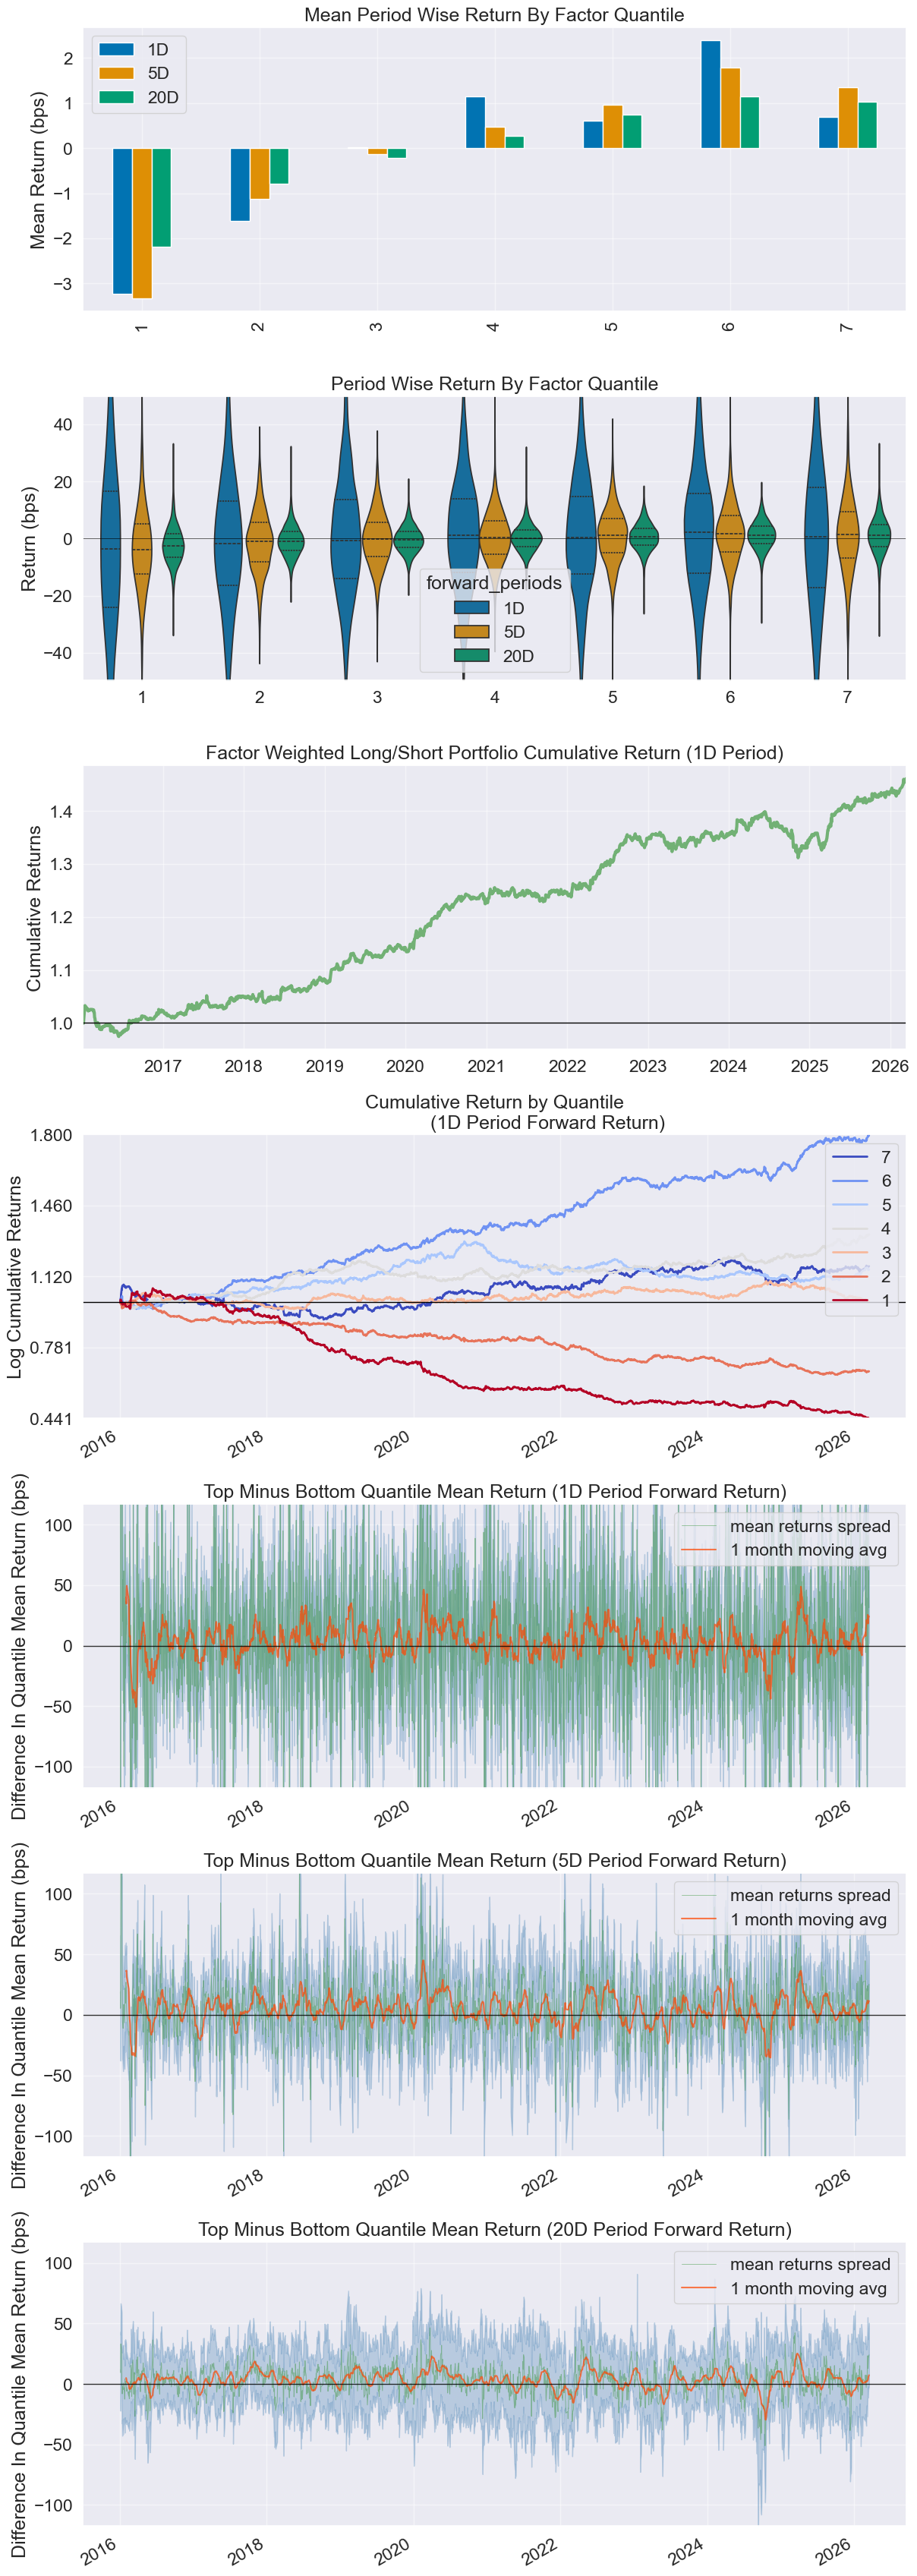

Information Analysis


,1D,5D,20D
IC Mean,0.012,0.026,0.035
IC Std.,0.074,0.073,0.065
Risk-Adjusted IC,0.159,0.354,0.532
t-stat(IC),7.891,17.595,26.481
p-value(IC),0.000,0.000,0.000
IC Skew,-0.017,-0.073,-0.164
IC Kurtosis,0.523,0.639,0.296


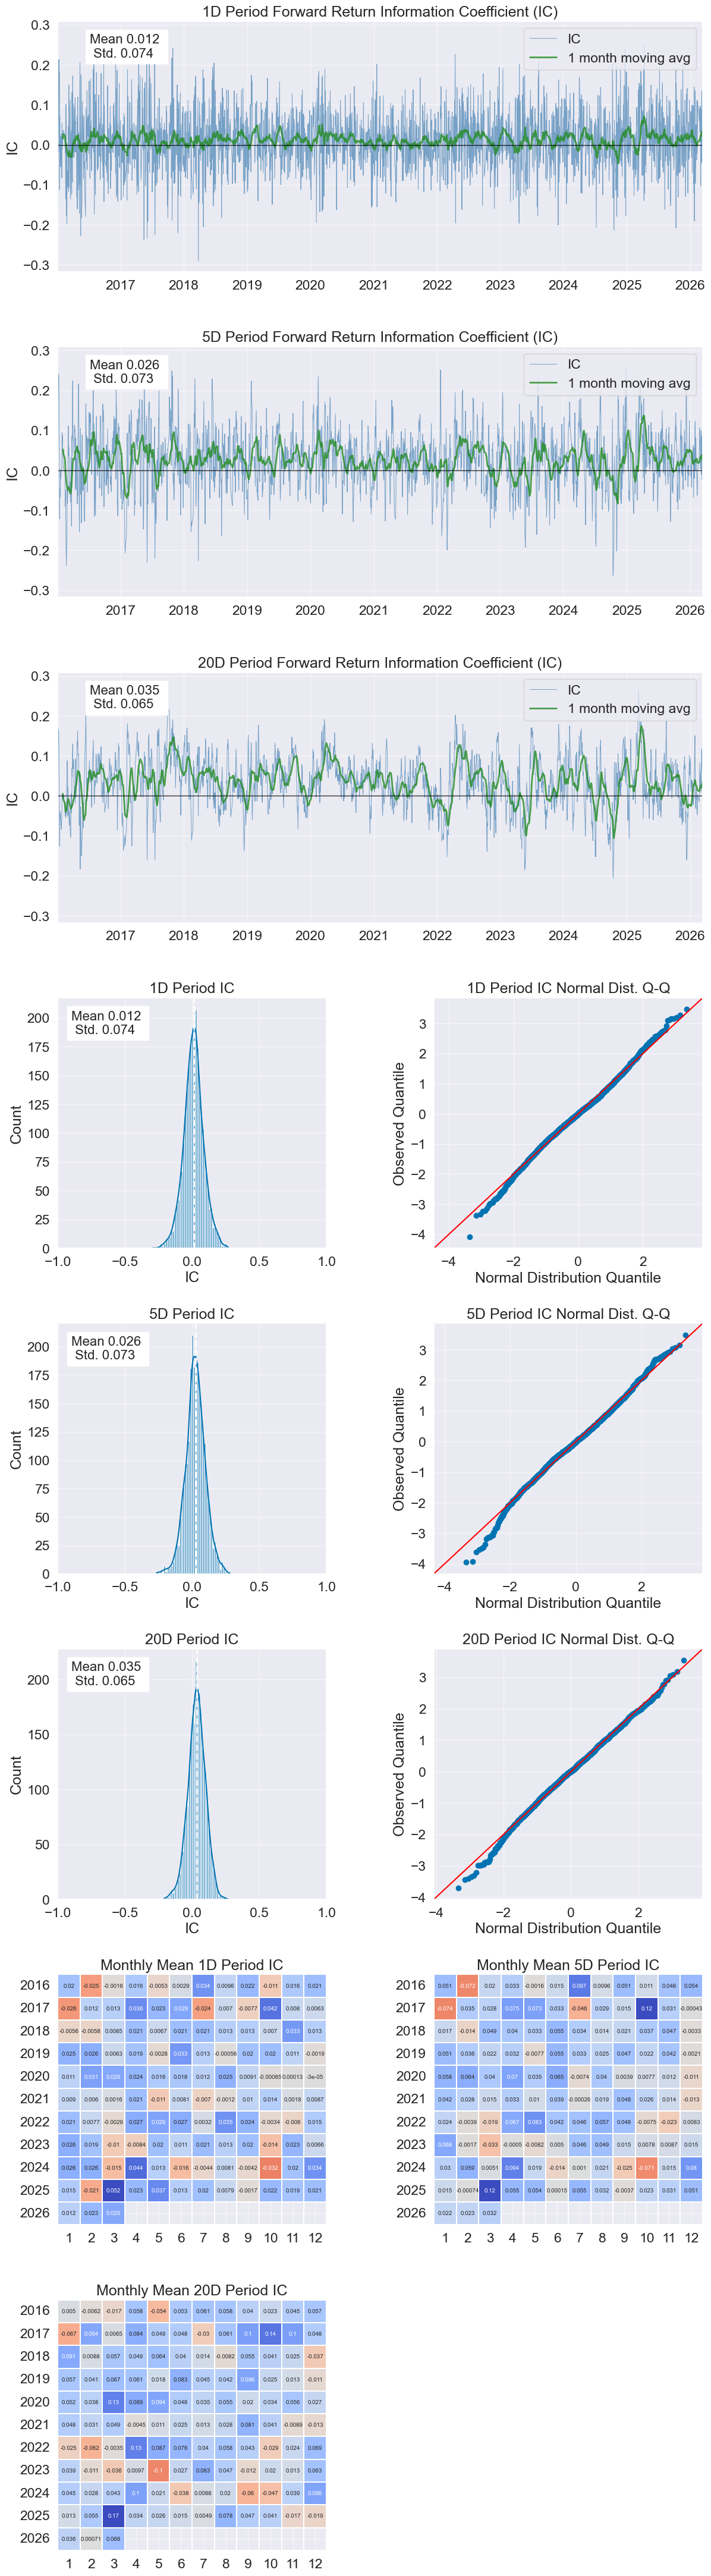

D:\anaconda3\envs\alphalens_env\Lib\site-packages\alphalens\utils.py:928: UserWarning: Skipping return periods that aren't exact multiples of days.
  warnings.warn(


Turnover Analysis


,1D,5D,20D
Quantile 1 Mean Turnover,0.284,0.722,0.833
Quantile 2 Mean Turnover,0.540,0.820,0.850
Quantile 3 Mean Turnover,0.619,0.840,0.857
Quantile 4 Mean Turnover,0.644,0.846,0.860
Quantile 5 Mean Turnover,0.627,0.839,0.855
Quantile 6 Mean Turnover,0.560,0.820,0.853
Quantile 7 Mean Turnover,0.305,0.728,0.835


,1D,5D,20D
Mean Factor Rank Autocorrelation,0.856,0.281,0.065


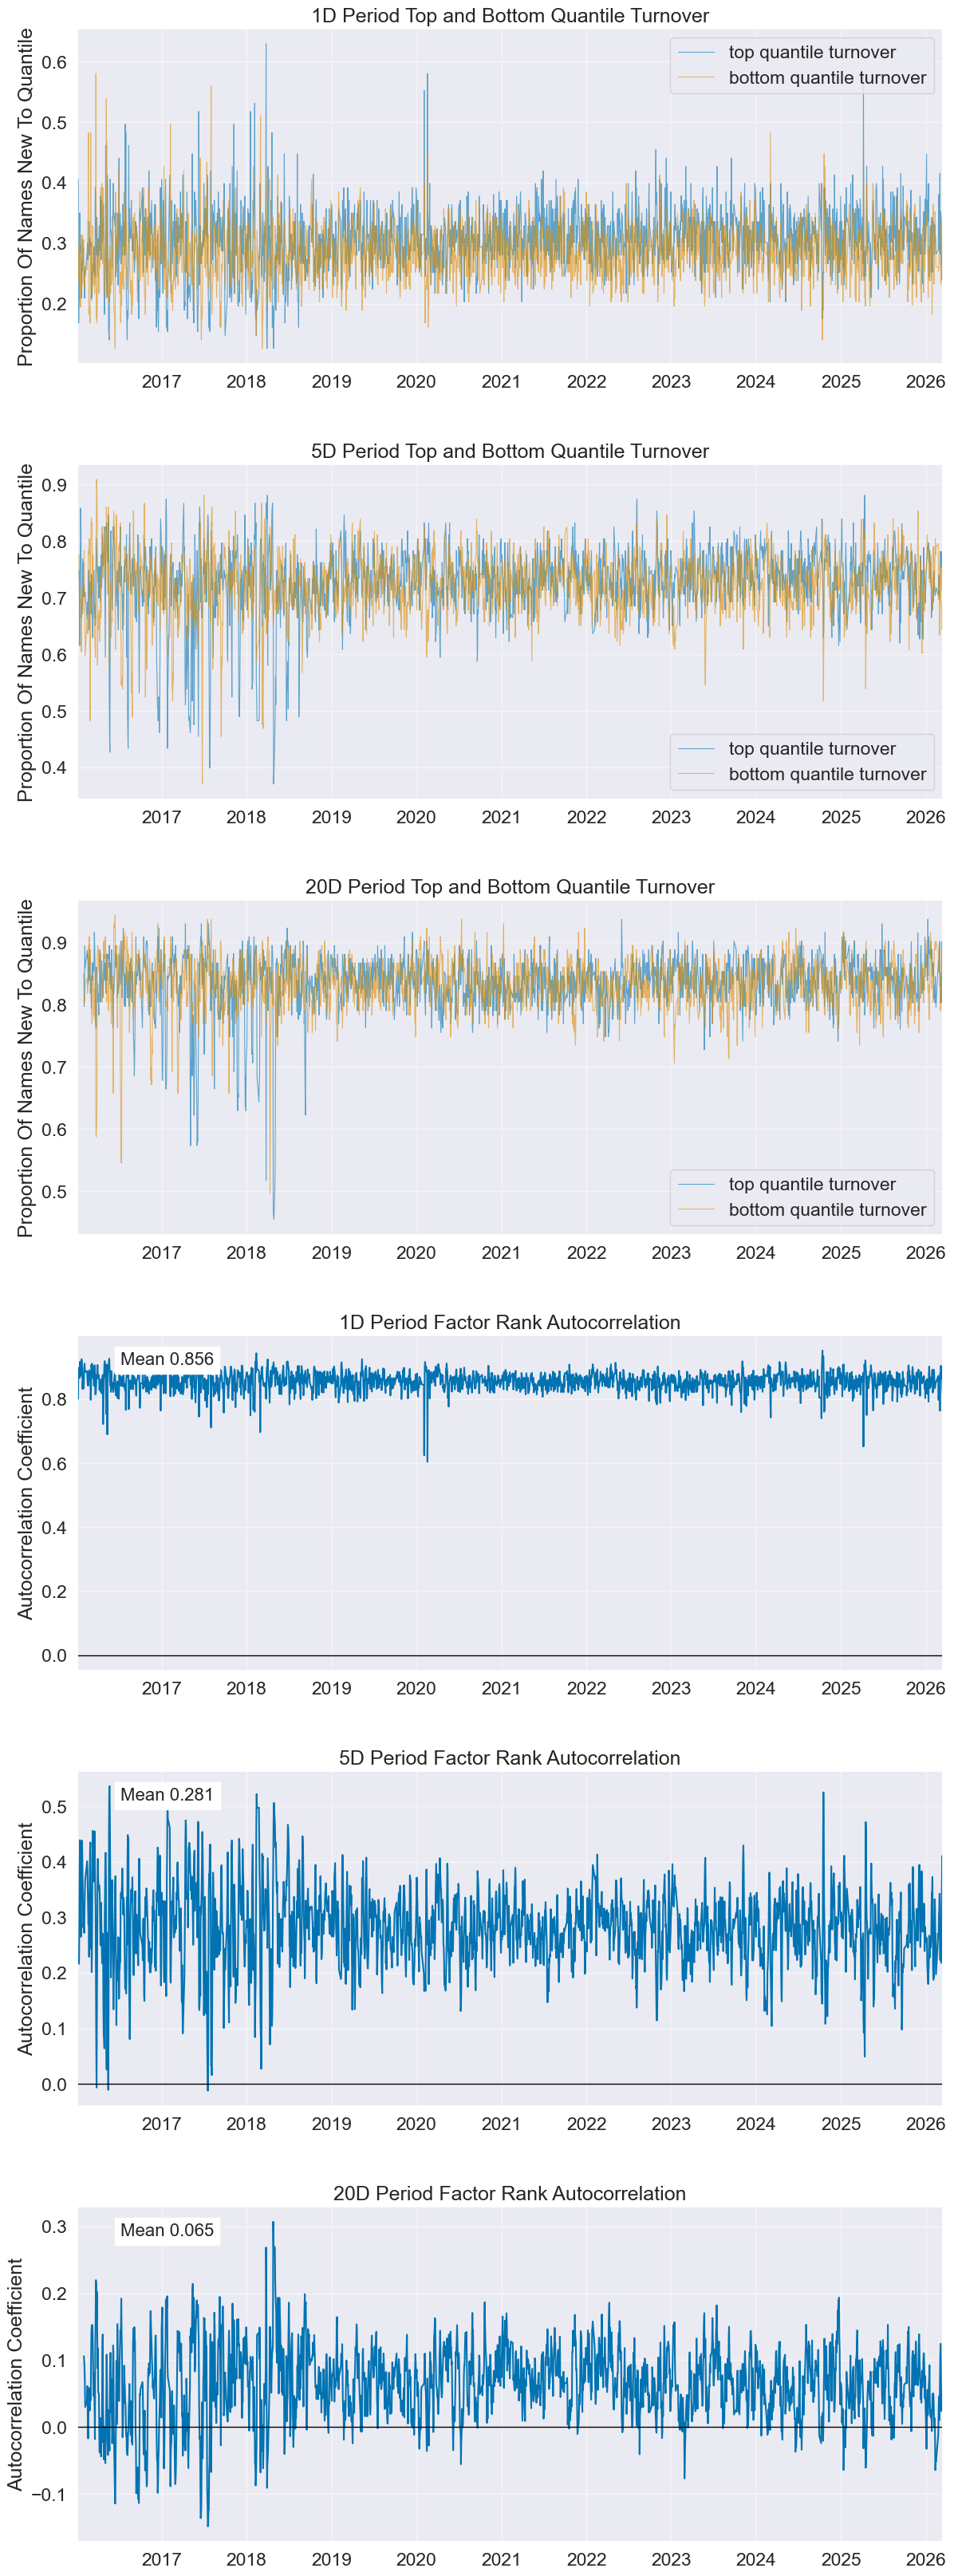

In [50]:
al.tears.create_full_tear_sheet(
    factor_data = factor_data,
    long_short = True,
    group_neutral = False,  # 替换 group_adjust
    by_group = False
)